<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  33.5MB/s    in 5.2s    

2026-08-26 06:17:00 (29.2 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



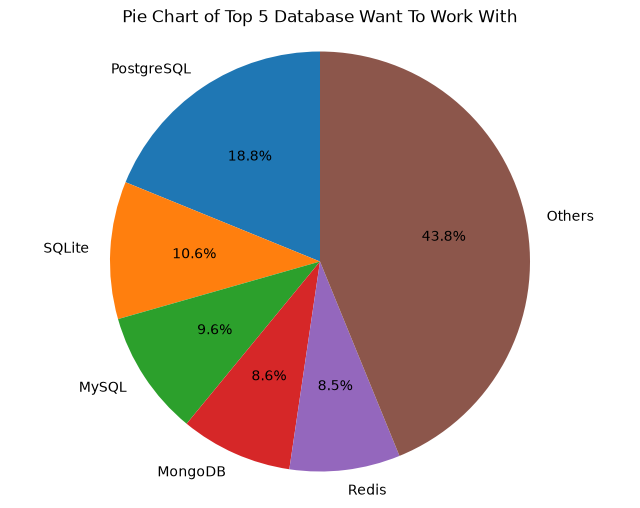

In [5]:
s = df["DatabaseWantToWorkWith"].dropna().str.split(";").explode()
df_counts = s.value_counts()

top5 = df_counts.head(5)
others_sum = df_counts[5:].sum()
if others_sum > 0:
    top5["Others"] = others_sum

plt.figure(figsize=(8, 6))
plt.pie(top5.values, labels=top5.index, autopct="%1.1f%%", startangle=90)
plt.title("Pie Chart of Top 5 Database Want To Work With")
plt.axis("equal")
plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



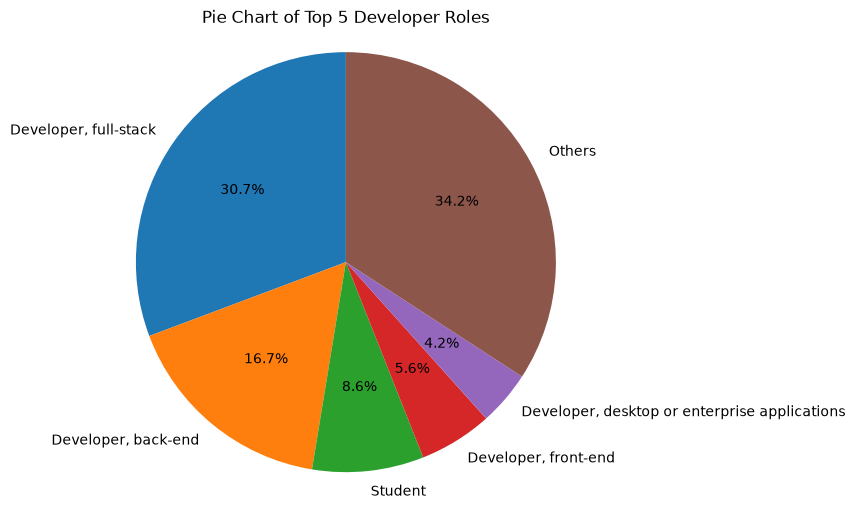

In [6]:
s_dev = df["DevType"].dropna().str.split(";").explode()
dev_counts = s_dev.value_counts()
top5_dev = dev_counts.head(5)
others_dev_sum = dev_counts[5:].sum()
top5_dev["Others"] = others_dev_sum

plt.figure(figsize=(8, 6))
plt.pie(
    top5_dev.values,
    labels=top5_dev.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Pie Chart of Top 5 Developer Roles")
plt.axis("equal")
plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



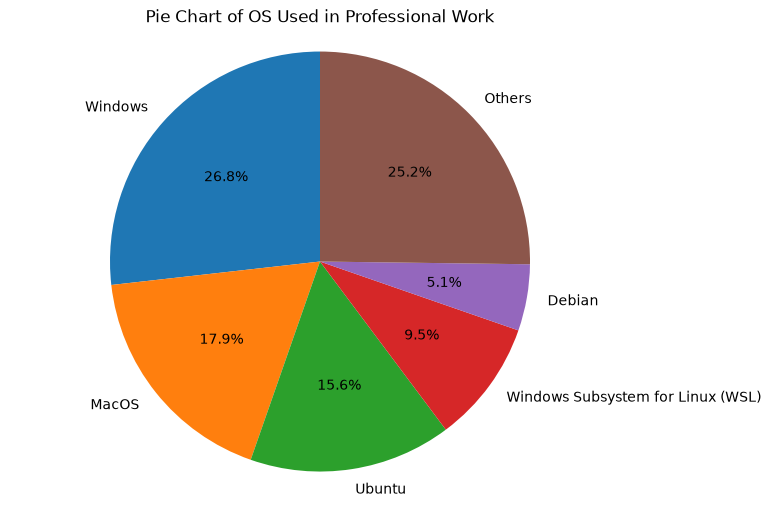

In [7]:
sys_series = df["OpSysProfessional use"].dropna().str.split(";").explode()
sys_counts = sys_series.value_counts()

top5_sys = sys_counts.head(5)
others_sys_sum = sys_counts[5:].sum()
top5_sys["Others"] = others_sys_sum

plt.figure(figsize=(8,6))
plt.pie(
    top5_sys.values,
    labels=top5_sys.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Pie Chart of OS Used in Professional Work")
plt.axis("equal")
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



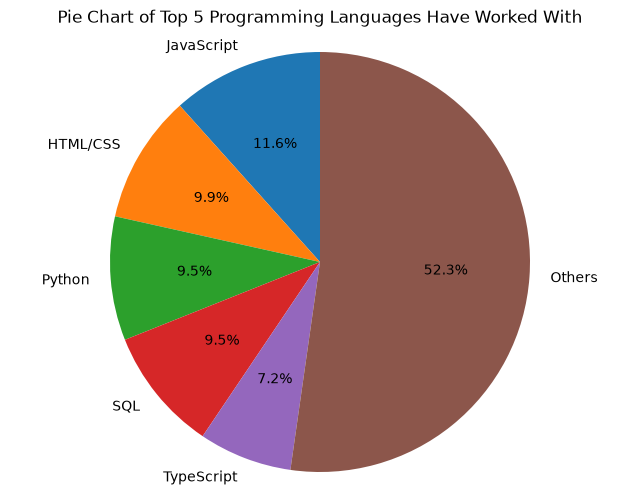

In [8]:
lang_series = df["LanguageHaveWorkedWith"].dropna().str.split(";").explode()
lang_counts = lang_series.value_counts()

top5_lang = lang_counts.head(5)
others_lang_sum = lang_counts[5:].sum()
top5_lang["Others"] = others_lang_sum
plt.figure(figsize=(8, 6))
plt.pie(
    top5_lang.values,
    labels=top5_lang.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Pie Chart of Top 5 Programming Languages Have Worked With")
plt.axis("equal")
plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



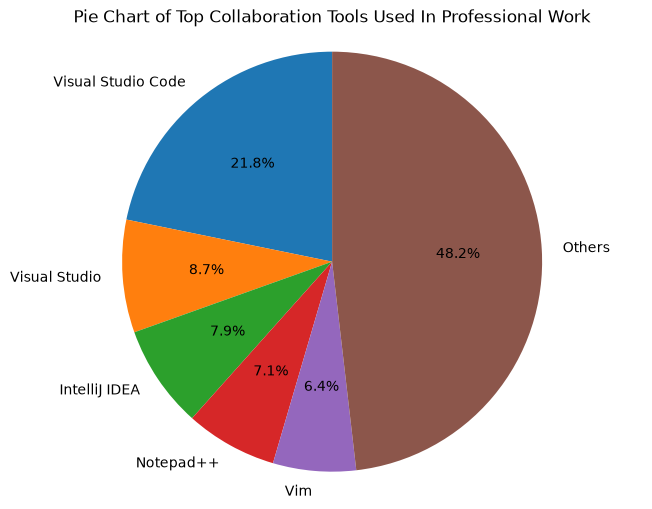

In [9]:
collab_series = df["NEWCollabToolsHaveWorkedWith"].dropna().str.split(";").explode()
collab_counts = collab_series.value_counts()
top5_collab = collab_counts.head(5)
others_collab_sum = collab_counts[5:].sum()
top5_collab["Others"] = others_collab_sum

plt.figure(figsize=(8, 6))
plt.pie(
    top5_collab.values,
    labels=top5_collab.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Pie Chart of Top Collaboration Tools Used In Professional Work")
plt.axis("equal")
plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



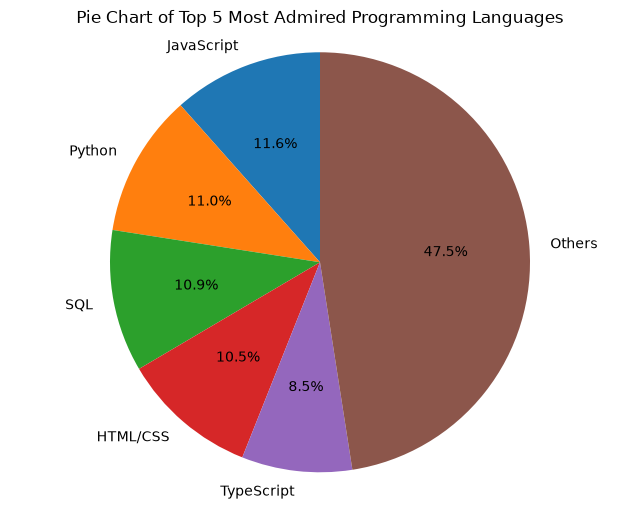

In [10]:
admired_series = df["LanguageAdmired"].dropna().str.split(";").explode()
admired_counts = admired_series.value_counts()
top5_admired = admired_counts.head(5)
others_admired_sum = admired_counts[5:].sum()
top5_admired["Others"] = others_admired_sum

plt.figure(figsize=(8, 6))
plt.pie(
    top5_admired.values,
    labels=top5_admired.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Pie Chart of Top 5 Most Admired Programming Languages")
plt.axis("equal")
plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



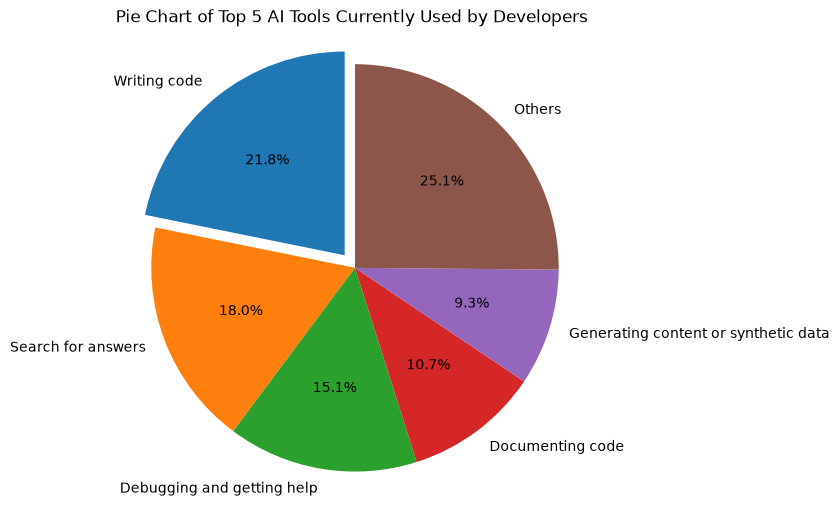

In [14]:
ai_series = df["AIToolCurrently Using"].dropna().str.split(";").explode()
ai_counts = ai_series.value_counts()
top5_ai = ai_counts.head(5)
others_ai_sum = ai_counts[5:].sum()
top5_ai["Others"] = others_ai_sum

plt.figure(figsize=(8, 6))
plt.pie(
    top5_ai.values,
    labels=top5_ai.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode
)
plt.title("Pie Chart of Top 5 AI Tools Currently Used by Developers")
plt.axis("equal")
plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



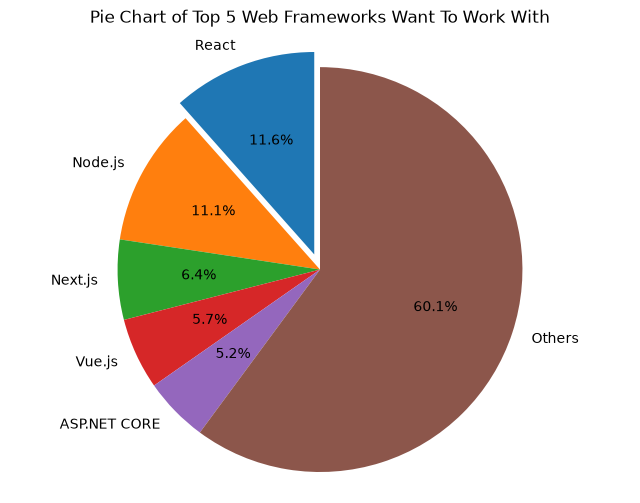

In [15]:
webframe_series = df["WebframeWantToWorkWith"].dropna().str.split(";").explode()
webframe_counts = webframe_series.value_counts()
top5_webframe = webframe_counts.head(5)
others_webframe_sum = webframe_counts[5:].sum()
top5_webframe["Others"] = others_webframe_sum
plt.figure(figsize=(8, 6))
explode = [0.08, 0, 0, 0, 0, 0]
plt.pie(
    top5_webframe.values,
    labels=top5_webframe.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode
)
plt.title("Pie Chart of Top 5 Web Frameworks Want To Work With")
plt.axis("equal")
plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



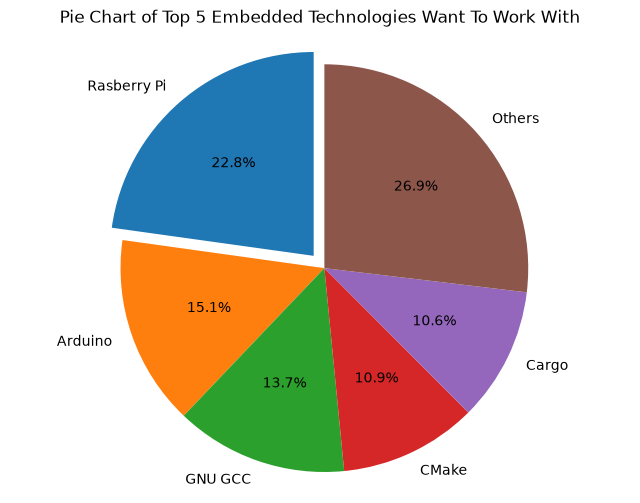

In [16]:
embedded_series = df["EmbeddedWantToWorkWith"].dropna().str.split(";").explode()
embedded_counts = embedded_series.value_counts()
top5_embedded = embedded_counts.head(5)
others_embedded_sum = embedded_counts[5:].sum()
top5_embedded["Others"] = others_embedded_sum
plt.figure(figsize=(8, 6))
explode = [0.08, 0, 0, 0, 0, 0]
plt.pie(
    top5_embedded.values,
    labels=top5_embedded.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode
)
plt.title("Pie Chart of Top 5 Embedded Technologies Want To Work With")
plt.axis("equal")
plt.show()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
